# National and Subnational Conflict Trends in Ethiopia

Using the ACLED dataset, this notebook explores the national and subnational trends, and spatial patterns in conflict events in Ethiopia. Two main periods of conflict are identified for review - 
- The Tigray War (Period I) between 3rd Nov 2020 - 3rd Nov 2022
- The ongoing Amhara War (Period II) between 1st April 2023 and 4th February 2026

## Assumptions and Considerations 

- The conflict events and fatalities included in the analysis are resulting from Riots, Explosions/Remote violence, Battles and Violence against civilians, Protests and Strategic Developments. All event types were included because they resulted in deaths in different periods. 
- We cannot say for certain that every fatality and event during this period is directly related to the actors involved in the war. It could also involve other conflict events that may have occurred during the same period. 
- The conflict data is extracted from ACLED, a crowdsourced, verified database of reported conflict events and fatalities. The results are extracted on February 5th 2026 and may change in the future based on new information received about estimated deaths and conflict events. 
- This work is still ongoing and the methodology is subject to change based on feedback, and peer review. 

## Definitions

The Conflict Intensity Index is calculated using the following formula:

**Conflict Intensity Index = √(Number of Events × (Number of Fatalities + 1))**

Where:
- **Number of Events**: Total count of conflict events in the given time period and location
- **Number of Fatalities**: Total number of fatalities from conflict events (adding 1 to avoid zero multiplication)
- The square root is applied to normalize the scale and reduce the impact of extreme values

This index provides a composite measure that accounts for both the frequency of conflicts (events) and their severity (fatalities), giving higher weight to areas with both frequent and deadly conflicts. 

## Ongoing Work

After an initial understanding of the spatial distribution of conflict, we are exploring the potential impact of conflict on agricultural activity in Ethiopia. We're using a difference-in-difference approach to see if proxies for crop yield measured using Enhanced Vegetation Index (EVI) have reduced in high conflict areas while controlling for the effects of rain, elevation, and land surface temperature. The analysis is being done in Tigray, Amhara, Oromia and Afar regions for the effects of the Tigray war and in the Amhara and Oromia regions to see the effects of the Amhara war. 

## Insights from Conflict Data

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import pandas as pd
from dotenv import load_dotenv
import altair as alt

# Enable Altair data transformer for larger datasets
alt.data_transformers.enable('default', max_rows=None)

# Load environment variables from .env file
load_dotenv('../../.env')

from acled_conflict_analysis import visuals
from acled_conflict_analysis import processing
from acled_conflict_analysis import extraction

from datetime import date
from datetime import datetime

In [2]:
from acled_visuals import *

In [3]:
from acled_conflict_analysis import extraction

import getpass
from datetime import datetime

countries_of_interest = ["Ethiopia"]
START_DATE = "2012-01-01"
END_DATE = datetime.today().strftime('%Y-%m-%d')


# acled_email = input("Enter your ACLED email: ")
# acled_password = getpass.getpass("Enter your ACLED password: ")

data = extraction.acled_api(
    country_codes=["ETH"],
    start_date=START_DATE,
    end_date=END_DATE  # Small date range for quick test
)


⏰ Cached token expired, refreshing...
🔐 Authenticating with ACLED API for : ssarva@worldbank.org
✅ Authentication successful!
Token expires in: 86400 seconds
💾 Token cached for future use
URL: https://acleddata.com/api/acled/read
Parameters: {'_format': 'json', 'limit': 4000000, 'iso': '231', 'event_date': '2012-01-01|2026-04-24', 'event_date_where': 'BETWEEN', 'population': 'full', 'fields': 'region|country|iso|year|event_date|source|admin1|admin2|admin3|location|event_type|sub_event_type|interaction|fatalities|timestamp|latitude|longitude|actor1|actor2|notes|population_1km|population_5km|population_2km|population_best'}
✅ Successfully retrieved 16495 records


In [4]:
extracted_date = datetime.today().strftime('%Y%m%d')
processing.data_type_conversion(data)
# data = data[data['event_type']!='Protests']
# data = data[data['event_type']!='Strategic developments']

In [5]:
import calendar


last_date = data['event_date'].max()
last_date = last_date.strftime('%d %b %Y')
# extracted_date_formatted = datetime.today().strftime('%d %b %Y')
# last_date = last_date.strftime('%d %B %Y')
extracted_date_formatted = datetime.today().strftime('%d %B %Y')

In [6]:
import pandas as pd
from datetime import datetime

def get_category(event_date):
    """
    Categorize events based on date ranges.
    
    Parameters:
    -----------
    event_date : datetime, pandas.Timestamp, or str
        The date of the event
        
    Returns:
    --------
    str
        The category of the event based on the date
    """
    # Convert string date to pandas Timestamp if it's not already
    if isinstance(event_date, str):
        event_date = pd.Timestamp(event_date)
    # Convert datetime to pandas Timestamp if it's not already
    elif isinstance(event_date, datetime):
        event_date = pd.Timestamp(event_date)
    
    # Make sure event_date is a pandas Timestamp
    if not isinstance(event_date, pd.Timestamp):
        raise TypeError("event_date must be a datetime, pandas.Timestamp, or string date")
    
    # Define the date range boundaries
    tigray_start = pd.Timestamp('2020-11-03')
    tigray_end = pd.Timestamp('2022-11-03')
    amhara_start = pd.Timestamp('2023-04-01')
    
    # Compare using proper timestamp comparison
    if tigray_start <= event_date <= tigray_end:
        return 'Tigray War'
    elif event_date >= amhara_start:
        return f'Amhara War'

In [7]:
data.to_csv(f'../../data/conflict/acled_raw_{extracted_date}.csv')

In [8]:
data['category'] = data['event_date'].apply(get_category)

In [9]:
ethiopia_adm0 = gpd.read_file('../../data/boundaries/eth_admbnda_adm0_csa_bofedb_itos_2021.shp')
ethiopia_adm1 = gpd.read_file('../../data/boundaries/Region_14/Regions_14.shp')
ethiopia_adm2 = gpd.read_file('../../boundaries/adm2_mapped.geojson')
ethiopia_adm3 = gpd.read_file('../../boundaries/adm3_mapped.geojson')

In [10]:
conflict_monthly = processing.get_acled_by_group(data, columns=['latitude', 'longitude'], freq='MS')
conflict_yearly = processing.get_acled_by_group(data, columns=['latitude', 'longitude'], freq='YS')
conflict_yearly_national = processing.get_acled_by_group(data, columns=['country'], freq='YS')
conflict_sub_event_type = processing.get_acled_by_group(data, columns = ['event_type', 'sub_event_type'], freq='QS')
conflict_event_type = processing.get_acled_by_group(data, columns = ['country','event_type'], freq='QS')

conflict_quarterly = processing.get_acled_by_group(data, columns=['latitude', 'longitude'], freq='QS')
conflict_quarterly_national = processing.get_acled_by_group(data, columns=['country'], freq='QS')

conflict_category = processing.get_acled_by_admin(ethiopia_adm1, data, ['ADM1_EN', 'category'])

In [11]:
events_dict = {datetime(2020, 11, 2):'Start of the Tigray War',
               #datetime(2022,3,29):'North Shewa Clashes',
    #datetime(2022, 11, 22):'Peace Agreement between \n  Ethiopia and TPLF',
    datetime(2023,4,9 ):'Start of the Amhara War'
               }

### Annual National Conflict Trends

There were a total of 8546 deaths from 1909 events in 2021. This was the highest in the last 10 years in Ethiopia. In 2024, there were 7564 fatalities from 3042 conflict events. 

In [12]:
fig = visuals.plot_conflict_trends_altair(
    conflict_yearly_national,
    "Annual Conflict Trends in Ethiopia",
    f"Source: ACLED. Accessed {extracted_date_formatted}",
    subtitle="",
    measures=["nrEvents", "nrFatalities"],
    plot_type="bar",
    width=275,
    height=175,
    bar_width_ratio=0.65,
    show_labels=False  # Add this to show labels
)

fig.show()

alt.VConcatChart(...)

In [13]:
fig = visuals.plot_conflict_trends_altair(
    conflict_quarterly_national,
    "Quarterly Conflict Trends in Ethiopia",
    f"Source: ACLED. Accessed {extracted_date_formatted}",
    subtitle="",
    measures=["nrEvents", "nrFatalities"],
    plot_type="line",
    width=275,
    height=175,
    bar_width_ratio=0.1,
    show_labels=False  # Add this to show labels
)

fig.show()

alt.VConcatChart(...)

### Annual Trends in Regions with High Fatalities

Subnationally, Amhara saw the highest number of conflict related deaths since 2012 with 15565 deaths, followed by Oromia (15197) and Tigray (5441). 

In [17]:
conflict_monthly_regional = processing.get_acled_by_admin(ethiopia_adm1, data, ['ADM1_EN'], freq='MS') 
conflict_yearly_regional = processing.get_acled_by_admin(ethiopia_adm1, data, ['ADM1_EN'], freq='YS') 

top5 = list(conflict_monthly_regional.groupby('ADM1_EN')['nrFatalities'].sum().reset_index().sort_values(by='nrFatalities',ascending=False).head(5)['ADM1_EN'])
top5

['Amhara', 'Oromia', 'Tigray', 'Benishangul Gumz', 'Somali']

In [18]:
fig = visuals.plot_lines_by_category_altair(
    conflict_yearly_regional[conflict_yearly_regional['ADM1_EN'].isin(top5)],
    "Annual Trends in Regions with Highest Fatalities",
    f"ACLED. Accessed {extracted_date_formatted}",
    category_column="ADM1_EN",
    measure="nrFatalities",
    width=400,
    height=250,
)
fig

alt.VConcatChart(...)

In [19]:
conflict_category_group = conflict_category.groupby(['category', 'ADM1_EN'])['nrFatalities'].sum().reset_index().sort_values(by=['nrFatalities', 'ADM1_EN'], ascending=False)

In [37]:
conflict_category_group.columns

Index(['category', 'ADM1_EN', 'nrFatalities'], dtype='object')

In [40]:
amhara_amhara = conflict_category_group[(conflict_category_group['ADM1_EN']=='Amhara')&(conflict_category_group['category']=='Amhara War')]['nrFatalities'].iloc[0]
oromia_amhara = conflict_category_group[(conflict_category_group['ADM1_EN']=='Oromia')&(conflict_category_group['category']=='Amhara War')]['nrFatalities'].iloc[0]

tigray_tigray = conflict_category_group[(conflict_category_group['ADM1_EN']=='Tigray')&(conflict_category_group['category']=='Tigray War')]['nrFatalities'].iloc[0]
oromia_tigray = conflict_category_group[(conflict_category_group['ADM1_EN']=='Oromia')&(conflict_category_group['category']=='Tigray War')]['nrFatalities'].iloc[0]
amhara_tigray = conflict_category_group[(conflict_category_group['ADM1_EN']=='Amhara')&(conflict_category_group['category']=='Tigray War')]['nrFatalities'].iloc[0]

In [42]:
from IPython.display import display, Markdown

display(Markdown(
    f"### Regional Fatalities by Period\n\n"
    f"Just during the period of the Amhara War, there were **{amhara_amhara:,}** deaths in Amhara and "
    f"**{oromia_amhara:,}** deaths in Oromia. During the Tigray War there were "
    f"**{tigray_tigray:,}** deaths in Tigray, **{oromia_tigray:,}** deaths in Oromia and "
    f"**{amhara_tigray:,}** deaths in Amhara."
))


### Regional Fatalities by Period

Just during the period of the Amhara War, there were **12,028** deaths in Amhara and **5,363** deaths in Oromia. During the Tigray War there were **5,001** deaths in Tigray, **4,888** deaths in Oromia and **3,444** deaths in Amhara.

In [20]:
import altair as alt

# Prepare data for both periods
tigray_data = conflict_category_group[conflict_category_group['category']=='Tigray War'].copy()
tigray_data['period'] = '3rd Nov 2020 - 3rd Nov 2022'

amhara_data = conflict_category_group[conflict_category_group['category']=='Amhara War'].copy()
amhara_data['period'] = f'3rd Apr 2023 - {datetime.today().strftime("%d %b %Y")}'

# Find max fatalities for shared scale
max_fatalities = max(tigray_data['nrFatalities'].max(), amhara_data['nrFatalities'].max())

# Create Tigray chart
tigray_chart = alt.Chart(tigray_data).mark_bar(color='#AA0000').encode(
    x=alt.X('nrFatalities:Q', 
            title='Number of Fatalities',
            scale=alt.Scale(domain=[0, max_fatalities * 1.05])),
    y=alt.Y('ADM1_EN:N', 
            title='',
            sort='-x')
).properties(
    width=250,
    height=400,
    title=alt.TitleParams(
        text='3rd Nov 2020 - 3rd Nov 2022',
        fontSize=14,
        fontWeight='bold',
        anchor='start'
    )
)

# Create Amhara chart
amhara_chart = alt.Chart(amhara_data).mark_bar(color='#AA0000').encode(
    x=alt.X('nrFatalities:Q', 
            title='Number of Fatalities',
            scale=alt.Scale(domain=[0, max_fatalities * 1.05])),
    y=alt.Y('ADM1_EN:N', 
            title='',
            sort='-x')
).properties(
    width=250,
    height=400,
    title=alt.TitleParams(
        text=f'3rd Apr 2023 - {datetime.today().strftime("%d %b %Y")}',
        fontSize=14,
        fontWeight='bold',
        anchor='start'
    )
)

# Combine charts
final_chart = (tigray_chart | amhara_chart).properties(
    title=alt.TitleParams(
        text='Regional Conflict Fatalities by Period',
        subtitle='Comparison of total fatalities across regions during Tigray and Amhara conflicts',
        fontSize=16,
        fontWeight='bold',
        anchor='start'
    )
).configure_view(
    strokeWidth=0
).configure_axis(
    grid=False
)

final_chart

alt.HConcatChart(...)

### Spatial Distribution of Conflict

To understand spatial distribution, we breakdown the country into hexagons of approximately 235 sqkm. On average, the size of an ADM3 unit in Ethiopia is 1043 sqkm. Using these grids (H3 grids resolution 5), we plot the total number of conflict events, conflict fatlities and conflict index. 

A total of 980 grids i.e., 230,300 sqkm of the area had atleast one conflict event or fatality during the Amhara War while 586 grids i.e., 137,710 sqkm had conflict events or fatalities during the Tigray War. This enabled us to posit that the impact of fatalities and cofnlcut events over the last two years are more widespread. Given the cofnlict is in agricultural land, we are now exploring the impacty of conflict on agriculture. 

In [21]:
import geopandas as gpd

eth_h3 = processing.convert_to_h3_grid(ethiopia_adm0, resolution=5)

In [22]:
category_list = ['Tigray War', f'Amhara War']

In [23]:
data['category'] = data['event_date'].apply(lambda x: get_category(x))
df = data[~(data['category'].isna())]

In [24]:
import numpy as np
conflict_monthly_h3 = processing.get_acled_by_admin(eth_h3, df, columns=['h3_index', 'category'], freq='MS', fatalities='fatalities')
conflict_monthly_h3.drop(columns=['index'], inplace=True)

conflict_monthly_h3['conflict_intensity_index_op1'] = np.sqrt((conflict_monthly_h3['nrEvents']) * 
                                           (conflict_monthly_h3['nrFatalities'] + 1))

conflict_monthly_h3 = conflict_monthly_h3.groupby(['h3_index', 'category'])[['nrEvents', 'nrFatalities', 'conflict_intensity_index_op1']].mean().reset_index()
conflict_monthly_h3 = eth_h3.merge(conflict_monthly_h3, on='h3_index', how='inner')

In [25]:
conflict_monthly_h3.to_file(f'../../data/conflict/acled_monthly_conflict_{extracted_date}.shp')

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_58256/2207045654.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  conflict_monthly_h3.to_file(f'../../data/conflict/acled_monthly_conflict_{extracted_date}.shp')
/Users/ssarva/Library/CloudStorage/OneDrive-WBG/Documents/ethiopia-economic-monitoring/.venv/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'nrFatalities' to 'nrFataliti'
  ogr_write(
/Users/ssarva/Library/CloudStorage/OneDrive-WBG/Documents/ethiopia-economic-monitoring/.venv/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'conflict_intensity_index_op1' to 'conflict_i'
  ogr_write(


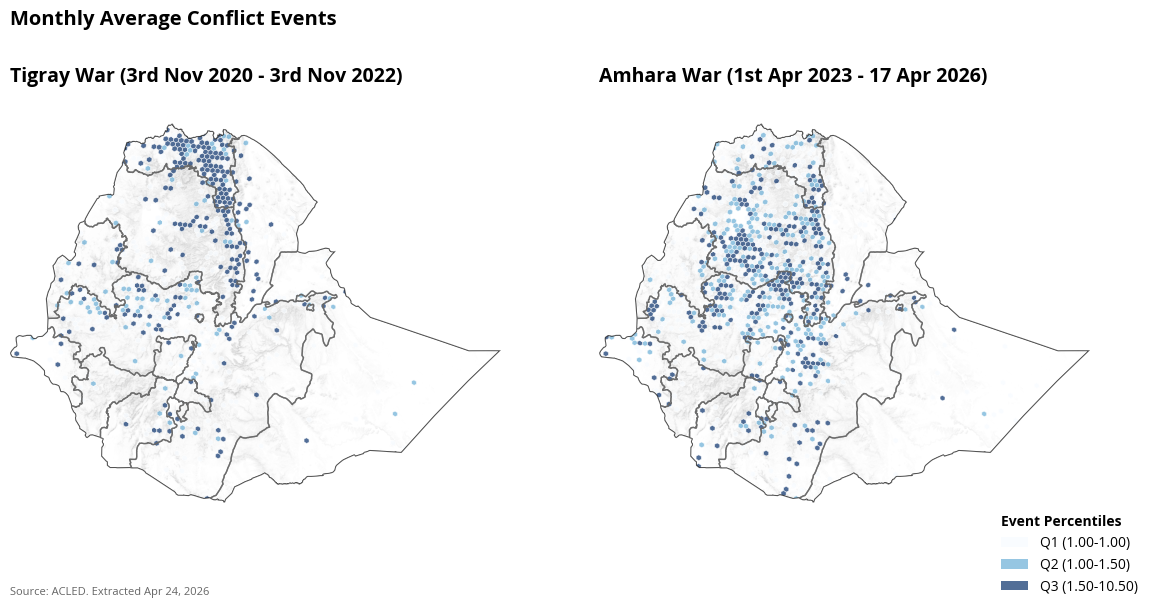

In [26]:
mapbox_token = os.getenv('MAPBOX_TOKEN')
mapbox_style_url = f'https://api.mapbox.com/styles/v1/sahitis/cmkpxgplb008v01s1cuaeg9br/tiles/256/{{z}}/{{x}}/{{y}}@2x?access_token={mapbox_token}&fresh=true'

fig, ax = visuals.get_h3_maps(
    conflict_monthly_h3, 
    'Monthly Average Conflict Events', 
    measure='nrEvents',
    figsize=(12,6),
    category_list=category_list,
    country_boundary=ethiopia_adm0,
    admin1_boundary=ethiopia_adm1,
    basemap_choice=mapbox_style_url,
    basemap_alpha=0.5,
    zoom=8,
    subplot_titles={
    category_list[0]: 'Tigray War (3rd Nov 2020 - 3rd Nov 2022)',
    category_list[1]: f'Amhara War (1st Apr 2023 - {last_date})'
},
title_pad=30,
    legend_title='Event Percentiles'
)

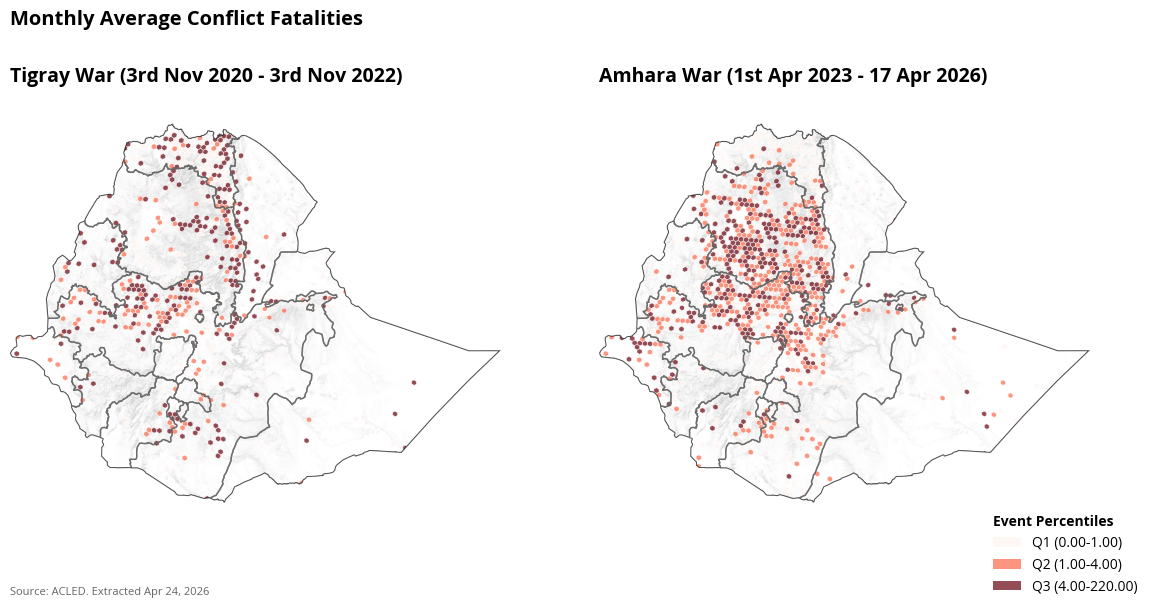

In [27]:
mapbox_token = os.getenv('MAPBOX_TOKEN')
mapbox_style_url = f'https://api.mapbox.com/styles/v1/sahitis/cmkpxgplb008v01s1cuaeg9br/tiles/256/{{z}}/{{x}}/{{y}}@2x?access_token={mapbox_token}&fresh=true'

fig, ax = visuals.get_h3_maps(
    conflict_monthly_h3, 
    'Monthly Average Conflict Fatalities', 
    measure='nrFatalities',
    figsize=(12,6),
    category_list=category_list,
    country_boundary=ethiopia_adm0,
    admin1_boundary=ethiopia_adm1,
    basemap_choice=mapbox_style_url,
    basemap_alpha=0.5,
    zoom=8,
    subplot_titles={
    category_list[0]: 'Tigray War (3rd Nov 2020 - 3rd Nov 2022)',
    category_list[1]: f'Amhara War (1st Apr 2023 - {last_date})'
},
title_pad=30,
    legend_title='Event Percentiles'
)

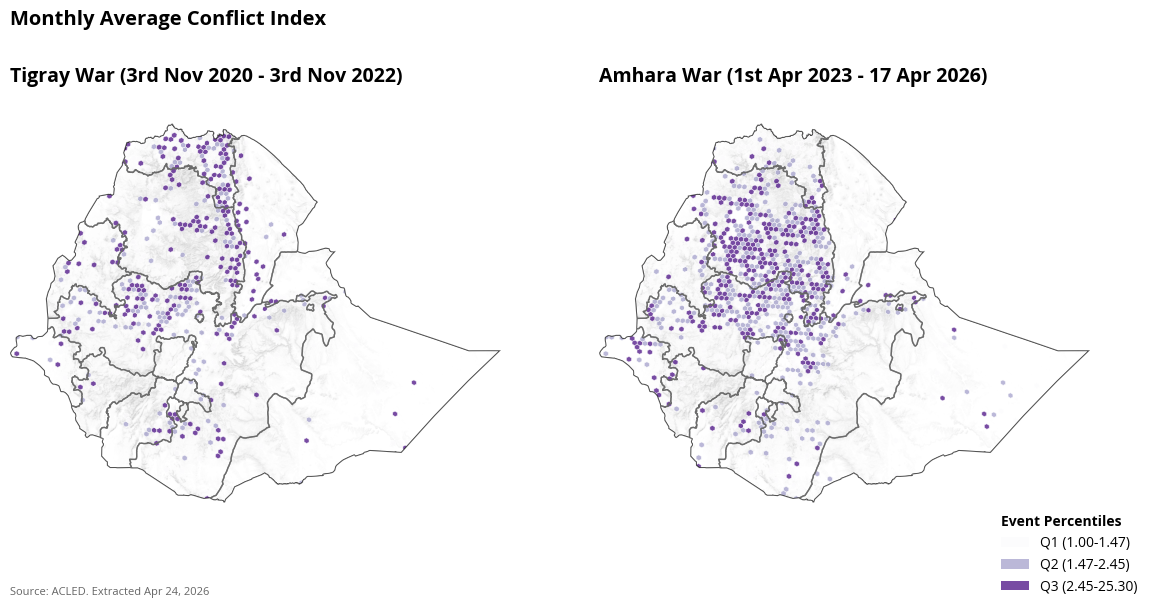

In [28]:
mapbox_token = os.getenv('MAPBOX_TOKEN')
mapbox_style_url = f'https://api.mapbox.com/styles/v1/sahitis/cmkpxgplb008v01s1cuaeg9br/tiles/256/{{z}}/{{x}}/{{y}}@2x?access_token={mapbox_token}&fresh=true'

fig, ax = visuals.get_h3_maps(
    conflict_monthly_h3, 
    'Monthly Average Conflict Index', 
    measure='conflict_intensity_index_op1',
    figsize=(12,6),
    category_list=category_list,
    country_boundary=ethiopia_adm0,
    admin1_boundary=ethiopia_adm1,
    basemap_choice=mapbox_style_url,
    basemap_alpha=0.5,
    zoom=8,
    subplot_titles={
    category_list[0]: 'Tigray War (3rd Nov 2020 - 3rd Nov 2022)',
    category_list[1]: f'Amhara War (1st Apr 2023 - {last_date})'
},
title_pad=30,
    legend_title='Event Percentiles'
)

## Population living in the same regions as conflict

In [29]:
#data.drop(columns=['Unnamed: 0'], inplace=True)

In [30]:
import mercantile
def get_quadkey_from_lat_lon(lat, lon, zoom=12):
    
    tile = mercantile.tile(lon, lat, zoom)
    quadkey = mercantile.quadkey(tile)
    return quadkey

In [31]:
data['quad13'] = data.apply(lambda row: get_quadkey_from_lat_lon(row['latitude'], row['longitude'], zoom=13), axis=1)

In [32]:
data['nrEvents'] = 1

In [33]:
# conflict_quad13 = data.groupby(['quad13', 'category'])[['nrFatalities','nrEvents']].sum().reset_index()
# conflict_quad13['category'].unique()

In [34]:
affected_quad_tigray = conflict_quad13[conflict_quad13['category'] == 'Tigray War (3rd Nov 2020 - 3rd Nov 2022)']['quad13'].unique()
affected_quad_amhara = conflict_quad13[conflict_quad13['category'] == f'Amhara War (1st Apr 2023 - {last_date})']['quad13'].unique()

NameError: name 'conflict_quad13' is not defined

In [ ]:
eth_worldpop = gpd.read_file('../../data/population/gdf_ETH.gpkg')
total_population = eth_worldpop['population'].sum()

In [ ]:
# import matplotlib.pyplot as plt

# # Create subplots side by side
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# # Plot Tigray conflict affected areas with population data
# tigray_pop = eth_worldpop[eth_worldpop['index'].isin(affected_quad_tigray)]
# tigray_pop.plot(column='population', legend=True, ax=ax1)
# #tigray_pop.plot(ax=ax1, column='population', cmap='Reds', legend=True, vmin=0, vmax=1000)
# ax1.set_title('Population in Tigray War Affected Areas\n(3rd Nov 2020 - 3rd Nov 2022)', fontsize=12)
# ethiopia_adm1.boundary.plot(ax=ax1, color='black', linewidth=0.5)
# ax1.set_axis_off()

# # Plot Amhara conflict affected areas with population data
# amhara_pop = eth_worldpop[eth_worldpop['index'].isin(affected_quad_amhara)]
# amhara_pop.plot(ax=ax2, column='population', legend=True)
# ax2.set_title(f'Population in Amhara War Affected Areas\n(1st Apr 2023 - {last_date})', fontsize=12)
# ethiopia_adm1.boundary.plot(ax=ax2, color='black', linewidth=0.5)
# ax2.set_axis_off()

# plt.tight_layout()
# plt.show()

# # # Print summary statistics
# print(f"Total population in Tigray conflict areas: {tigray_pop['population'].sum():,.0f}. This is {100*tigray_pop['population'].sum()/total_population:.2f}% of Ethiopia's total population of {total_population:,.0f}.")
# print(f"Total population in Amhara conflict areas: {amhara_pop['population'].sum():,.0f}. This is {100*amhara_pop['population'].sum()/total_population:.2f}% of Ethiopia's total population of {total_population:,.0f}.")
# print(f"Average population density in Tigray areas: {tigray_pop['population'].mean():,.0f}")
# print(f"Average population density in Amhara areas: {amhara_pop['population'].mean():,.0f}")

### Subnational Trends 

In [ ]:
fig = visuals.plot_conflict_by_category_altair(
    conflict_yearly_regional.sort_values("nrFatalities", ascending=False),
    "Fatalities by Conflict Types",
    "ACLED. Accessed 19th September 2024",
    category_column="ADM1_EN",
    measure="nrFatalities",
    plot_type="bar",
    width=180,
    height=100,
    n_cols=3,
    bar_width_ratio=0.15
)
fig

alt.VConcatChart(...)

### Conflict Trends by Type

In [ ]:
fig = visuals.plot_conflict_by_category_altair(
    conflict_event_type,
    "Quarterly Fatalities by Conflict Types",
    f"ACLED. Accessed {extracted_date_formatted}",
    category_column="event_type",
    measure="nrFatalities",
    plot_type="bar",
    width=275,
    height=200,
    n_cols=2,
    bar_width_ratio=0.1
)
fig

alt.VConcatChart(...)